In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
print("Downloading stock data...")
tickers = "SOXL"
df = yf.download(tickers, period="60d", interval="5m")


[*********************100%***********************]  1 of 1 completed


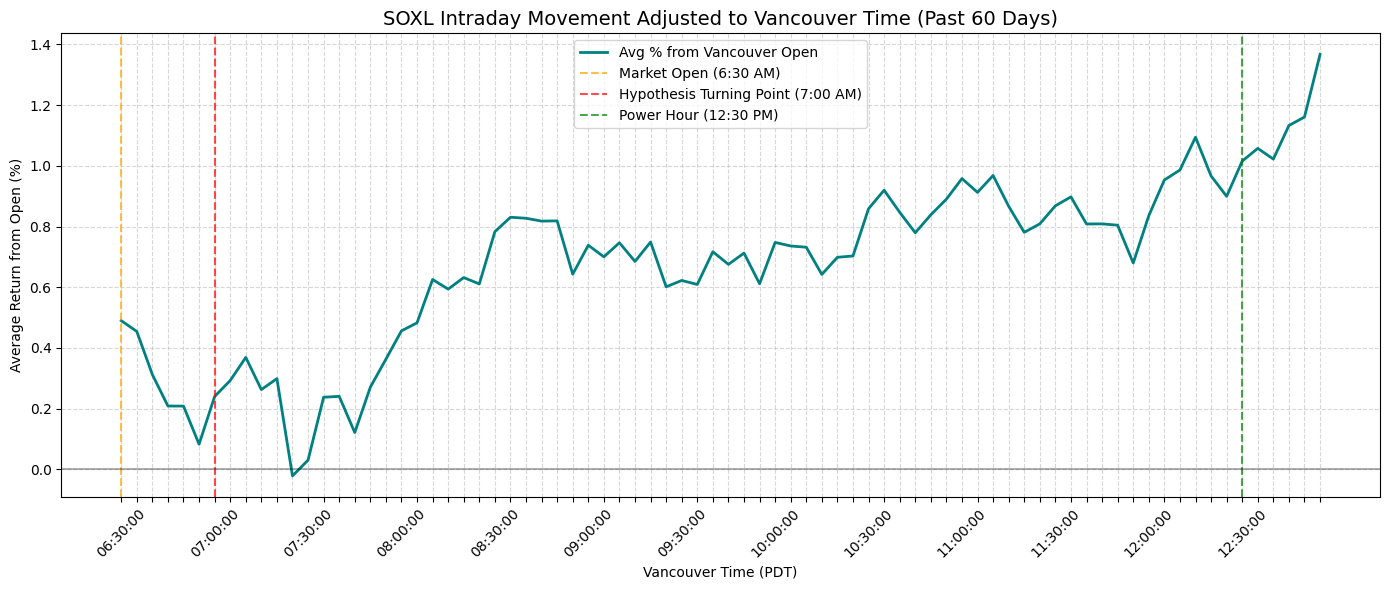

In [20]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

if df.empty:
    print("No data available.")
else:
    df = df.reset_index()
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = [col[0] if col[1] == '' else col[0] for col in df.columns]
    
    # 1. 데이터의 시간대를 뉴욕 시간에서 밴쿠버 시간(America/Vancouver)으로 변환
    df['Datetime_Van'] = df['Datetime'].dt.tz_convert('America/Vancouver')
    df['Time_Van'] = df['Datetime_Van'].dt.time
    df['Date_Van'] = df['Datetime_Van'].dt.date
    
    # 2. 당일 밴쿠버 시간 06:30(시가)을 기준으로 당일 변동률 계산
    df['Daily_Open'] = df.groupby('Date_Van')['Open'].transform('first')
    df['Pct_From_Open'] = ((df['Close'] - df['Daily_Open']) / df['Daily_Open']) * 100

    # 3. 밴쿠버 정규장 시간(06:30 ~ 13:00)만 필터링
    start_market = pd.to_datetime('06:30').time()
    end_market = pd.to_datetime('13:00').time()
    df_vancouver = df[(df['Time_Van'] >= start_market) & (df['Time_Van'] <= end_market)]
    
    # 시간대별 평균 변동률 계산
    time_summary = df_vancouver.groupby('Time_Van')['Pct_From_Open'].mean().reset_index()

    # 4. 밴쿠버 시간 기준으로 시각화
    plt.figure(figsize=(14, 6))
    plt.plot(time_summary['Time_Van'].astype(str), time_summary['Pct_From_Open'], 
             label='Avg % from Vancouver Open', color='teal', linewidth=2)
    
    # 밴쿠버 시간 가독성을 위해 30분 단위 표기
    plt.xticks(rotation=45)
    ax = plt.gca()
    for index, label in enumerate(ax.xaxis.get_ticklabels()):
        if index % 6 != 0:
            label.set_visible(False)
            
    # 가설에 언급된 핵심 시간대에 수직선 표시
    plt.axvline(x='06:30:00', color='orange', linestyle='--', alpha=0.7, label='Market Open (6:30 AM)')
    plt.axvline(x='07:00:00', color='red', linestyle='--', alpha=0.7, label='Hypothesis Turning Point (7:00 AM)')
    plt.axvline(x='12:30:00', color='green', linestyle='--', alpha=0.7, label='Power Hour (12:30 PM)')
    
    plt.title(f"SOXL Intraday Movement Adjusted to Vancouver Time (Past 60 Days)", fontsize=14)
    plt.xlabel("Vancouver Time (PDT)")
    plt.ylabel("Average Return from Open (%)")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.axhline(0, color='black', linestyle='-', alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

Total trading days analyzed: 60

[가장 최저점이 많이 발생한 상위 5개 시간대]
- 밴쿠버 시간 06:30 : 확률 30.00%
- 밴쿠버 시간 06:55 : 확률 8.33%
- 밴쿠버 시간 07:20 : 확률 5.00%
- 밴쿠버 시간 08:05 : 확률 5.00%
- 밴쿠버 시간 07:00 : 확률 3.33%


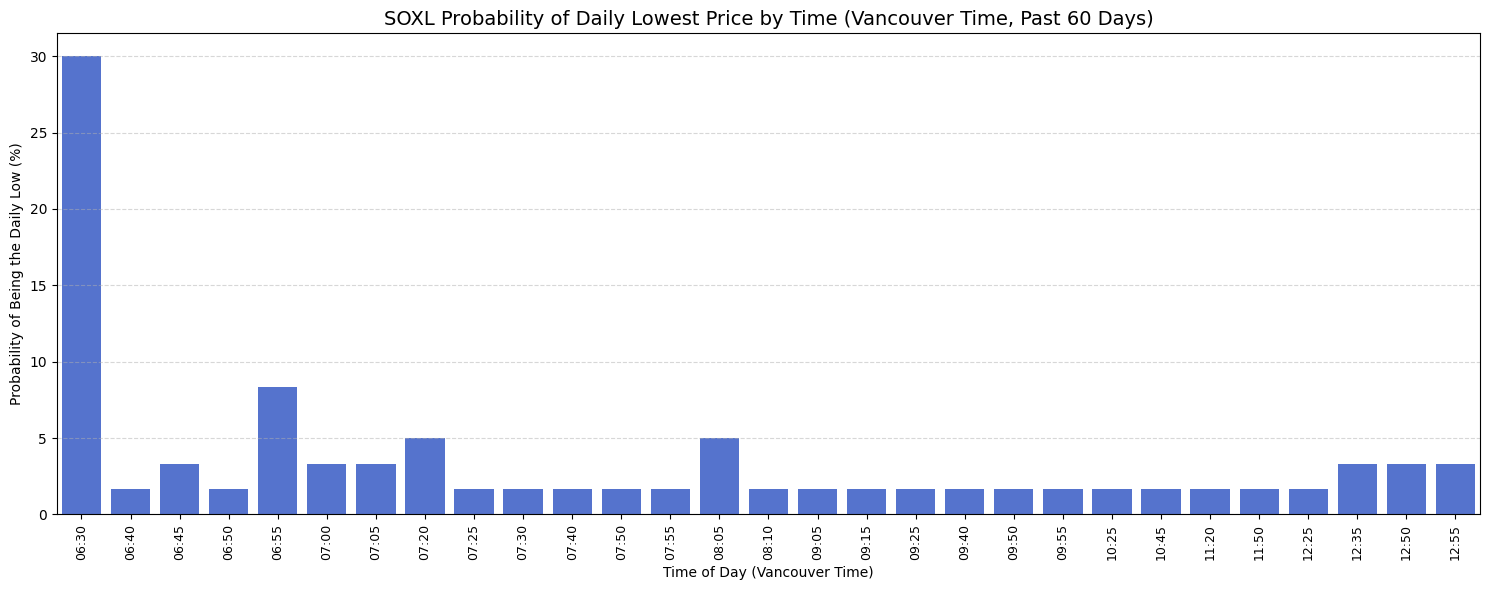

In [19]:
# 1. 매일매일 'Low_SOXL' 컬럼이 가장 낮았던 행(Row)의 인덱스 추출
idx_min = df_vancouver.groupby('Date_Van')['Low'].idxmin()
df_lowest_times = df_vancouver.loc[idx_min].copy()

# 2. 총 분석 거래일 수 계산 및 출력
total_days = len(df_lowest_times)
print(f"Total trading days analyzed: {total_days}")

# 3. 시간 데이터를 문자열 형태(HH:MM)로 포맷팅하여 빈도수 계산
df_lowest_times['Time_Str'] = df_lowest_times['Time_Van'].astype(str).str[:5]
time_counts = df_lowest_times['Time_Str'].value_counts().sort_index()

# 4. 빈도수를 기반으로 한 발생 확률(%) 계산
time_probabilities = (time_counts / total_days) * 100

# 5. 확률 분포 시각화 (Seaborn 막대그래프)
plt.figure(figsize=(15, 6))
sns.barplot(x=time_probabilities.index, y=time_probabilities.values, color='royalblue')

plt.title("SOXL Probability of Daily Lowest Price by Time (Vancouver Time, Past 60 Days)", fontsize=14)
plt.xlabel("Time of Day (Vancouver Time)")
plt.ylabel("Probability of Being the Daily Low (%)")
plt.xticks(rotation=90, fontsize=9)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# 6. 최저점이 가장 빈번하게 발생한 상위 5개 핫스팟 시간대 출력
print("\n[가장 최저점이 많이 발생한 상위 5개 시간대]")
top_times = time_probabilities.sort_values(ascending=False).head(5)
for t, p in top_times.items():
    print(f"- 밴쿠버 시간 {t} : 확률 {p:.2f}%")
    
plt.tight_layout()
plt.show()